# S-inhibition emergence — full sweep (5 Pythia sizes)

Goldowsky-Dill 2023 path-patching detector with frozen paths across Pythia-70m, 160m, 410m, 1b, 2.8b; locked threshold τ_strict = 0.0372 (§S-tau).

- **70m / 160m / 410m / 1b:** 40 log-spaced checkpoints per §H2-1.
- **2.8b:** **32 cells** merging §H4-supersede (10 cells, steps 5000-70000) with §H4-fullgrid (22 cells, steps 128-17000 + 84000-143000) per §H4-fullgrid (2026-05-12). §H4-supersede (2026-05-10) registered the reduced 10-cell grid and PASSed both (A.timing) and (A.count) gates on 2026-05-11; §H4-fullgrid then completed the §H2-1 40-cell grid by running the 22 cells missing from the §H4-supersede + §H4-7-supersede sub-grids, resolving the §writeup-conv-2 late-tail dip caveat. The 2.8b column is authorized for 5-size visualization by §writeup-conv-4 (§H4-supersede-vis).

Prompt-bootstrap CIs on μ per §H2-2 are computed for sizes with full 40-cell sweeps; the 2.8b column's μ is computed against the 10-cell §H4-supersede grid only (this is what §H4-supersede registered as the canonical 2.8b detection grid).

**§writeup-conv-4 caveat:** 2.8b is presentation-only. The registered §H1-C Track-1 emergence claim remains locked to 70m / 160m / 410m per §H2-1.

**Locked thresholds:**
- Detection threshold: Δ_h ≥ τ_strict = 0.0372 (§S-tau).
- Bootstrap: per-prompt resampling, B = 1000, 95% percentile CI.
- Tiered fit handling: emerged (max ≥ 5), marginal (2-4), censored (max < 2).

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long
from src.analysis.phase2_logistic import tiered_fit, RIGHT_CENSOR_STEP
from src.analysis.phase2_bootstrap import (
    bootstrap_s_inhibition, summarize_bootstrap, THRESHOLD_SENSITIVITY_FRACTIONS,
)

SIZES = ['70m', '160m', '410m', '1b', '2.8b']
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green', '1b': 'tab:red', '2.8b': 'tab:purple'}
TAU_STRICT = 0.0372

# 2.8b is loaded from two parquets per §H4-supersede + §H4-fullgrid (2026-05-12):
# the §H4-supersede 10-cell sweep is concatenated with the §H4-fullgrid 22-cell sweep
# (the cells missing from the §H4-supersede + §H4-7-supersede sub-grids) to recover
# the full §H2-1 40-cell grid coverage at 2.8b. Dedup by (size, step, layer, head),
# keep first (supersede preferred where overlap exists).
SWEEP_2_8B_SUPERSEDE = 'phase4_2_8b_s_inhibition_supersede_sweep.parquet'
SWEEP_2_8B_FULLGRID = 'phase4_2_8b_s_inhibition_fullgrid_sweep.parquet'
PER_PROMPT_2_8B_SUPERSEDE = 'phase4_2_8b_s_inhibition_supersede_per_prompt'
PER_PROMPT_2_8B_FULLGRID = 'phase4_2_8b_s_inhibition_fullgrid_per_prompt'


def sweep_path(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_s_inhibition_sweep.parquet'
    if size == '2.8b':
        # Returns the §H4-supersede path; callers needing the merged 2.8b view
        # should use load_sweep() below which merges supersede + fullgrid.
        return REPO / 'data' / 'exploration' / SWEEP_2_8B_SUPERSEDE
    return REPO / 'data' / 'exploration' / 'phase2_s_inhibition_sweep.parquet'


def load_sweep(size: str) -> pd.DataFrame:
    """Load the per-size sweep. For 2.8b, merges §H4-supersede + §H4-fullgrid."""
    if size == '2.8b':
        d1 = read_long(REPO / 'data' / 'exploration' / SWEEP_2_8B_SUPERSEDE)
        d2 = read_long(REPO / 'data' / 'exploration' / SWEEP_2_8B_FULLGRID)
        merged = pd.concat([d1, d2]).drop_duplicates(
            subset=['size', 'step', 'layer', 'head'], keep='first'
        ).reset_index(drop=True)
        return merged
    return read_long(sweep_path(size))


def per_prompt_dir(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_s_inhibition_per_prompt'
    if size == '2.8b':
        # Returns the §H4-supersede per-prompt dir; for steps that live only in
        # §H4-fullgrid (e.g. step 128, step 143000), use per_prompt_load() below.
        return REPO / 'data' / 'exploration' / PER_PROMPT_2_8B_SUPERSEDE
    return REPO / 'data' / 'exploration' / 'phase2_s_inhibition_per_prompt'


def per_prompt_load(size: str, step: int) -> np.lib.npyio.NpzFile:
    """Load per-prompt .npz, checking both §H4-supersede and §H4-fullgrid dirs for 2.8b."""
    if size == '2.8b':
        for sub in (PER_PROMPT_2_8B_SUPERSEDE, PER_PROMPT_2_8B_FULLGRID):
            p = REPO / 'data' / 'exploration' / sub / f'{size}_step{step}.npz'
            if p.exists():
                return np.load(p)
        raise FileNotFoundError(f'No per-prompt npz for 2.8b step {step}')
    return np.load(per_prompt_dir(size) / f'{size}_step{step}.npz')


## Load sweep data

In [2]:
# Load all 5 sizes. 70m/160m/410m share phase2_s_inhibition_sweep.parquet (so we
# dedup parquet paths to avoid triple-counting), 1b is its own parquet, and 2.8b is
# the merged §H4-supersede + §H4-fullgrid view per §H4-fullgrid (2026-05-12).
_phase2 = read_long(sweep_path('70m'))  # holds 70m, 160m, 410m
_p1b = read_long(sweep_path('1b'))
_p2_8b = load_sweep('2.8b')  # merged supersede + fullgrid
df = pd.concat([_phase2, _p1b, _p2_8b]).reset_index(drop=True)
STEPS = sorted(df.step.unique().tolist())
n_per_size = df.groupby('size')['step'].nunique().to_dict()
print(f'Total rows: {len(df):,}; sizes: {sorted(df["size"].unique().tolist())}; cells/size: {n_per_size}')


Total rows: 60,928; sizes: ['160m', '1b', '2.8b', '410m', '70m']; cells/size: {'160m': 40, '1b': 40, '2.8b': 32, '410m': 40, '70m': 40}


## Per-cell summary: count of S-inhibition heads (Δ_h ≥ τ_strict)

In [3]:
summary_rows = []
for (size, step), grp in df.groupby(['size', 'step']):
    scores = grp['score'].values
    n_above = int((scores >= TAU_STRICT).sum())
    summary_rows.append(dict(
        size=size, step=step,
        n_above_tau=n_above,
        max_delta=float(scores.max()),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_above_tau  max_delta
 70m      0            0   0.000105
 70m      1            0   0.000105
 70m      2            0   0.000106
 70m      4            0   0.000106
 70m      8            0   0.000095
 70m     16            0   0.000052
 70m     32            0   0.000017
 70m     64            0   0.000024
 70m    128            0   0.000031
 70m    256            0   0.000047
 70m    512            0   0.000226
 70m   1000            0   0.000036
 70m   2000            0   0.000104
 70m   3000            0   0.000107
 70m   4000            0   0.002010
 70m   5000            0   0.002276
 70m   6000            0   0.001941
 70m   7000            0   0.004289
 70m   8000            0   0.001875
 70m   9000            0   0.002449
 70m  10000            0   0.002116
 70m  11000            0   0.003443
 70m  12000            0   0.002645
 70m  13000            0   0.006321
 70m  14000            0   0.002454
 70m  15000            0   0.004798
 70m  16000            0   0

## Emergence curves with bootstrap CI on μ

In [4]:
rng = np.random.default_rng(0)
fits = {}
boots = {}
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    counts = sub['n_above_tau'].values
    per_prompt_by_step = {}
    nm_layers_by_step = {}
    for s in steps:
        npz = per_prompt_load(size, int(s))
        per_prompt_by_step[int(s)] = npz['per_prompt_delta']
        nm_layers_by_step[int(s)] = npz['nm_heads'][:, 0].tolist()
    # Sender layers: first column of (layer, head) for n_layers × n_heads.
    a_step = steps[0]
    n_senders = per_prompt_by_step[a_step].shape[0]
    # Sender layer = senders[i][0]; runner used row-major (L, H) over all heads.
    # Reconstruct: senders = [(L, H) for L in range(n_layers) for H in range(n_heads)].
    a_grp = df[(df['size'] == size) & (df['step'] == a_step)]
    n_layers = int(a_grp['layer'].max() + 1)
    n_heads = int(a_grp['head'].max() + 1)
    sender_layers = np.array([L for L in range(n_layers) for _ in range(n_heads)])
    mus, mu_point = bootstrap_s_inhibition(
        per_prompt_by_step, TAU_STRICT, nm_layers_by_step, sender_layers, rng, B=1000,
    )
    bres = summarize_bootstrap(size, 's_inhibition', TAU_STRICT, mus, mu_point)
    fr = tiered_fit(size, 's_inhibition', steps, counts,
                    bootstrap_median_mu=bres.mu_bootstrap_median)
    fits[size] = fr
    boots[size] = bres
    print(f'{size}: regime={fr.regime}, max_count={fr.max_count}, μ_point={fr.mu:.0f}, '
          f'μ_boot=[{bres.mu_ci_low:.0f}, {bres.mu_ci_high:.0f}]')

70m: regime=censored, max_count=1, μ_point=143000, μ_boot=[143000, 143000]


160m: regime=marginal, max_count=3, μ_point=2000000, μ_boot=[7485, 2000000]


410m: regime=marginal, max_count=3, μ_point=24616, μ_boot=[21552, 41453]


1b: regime=marginal, max_count=3, μ_point=4017, μ_boot=[3997, 4499]


2.8b: regime=emerged, max_count=5, μ_point=8695, μ_boot=[7889, 8976]


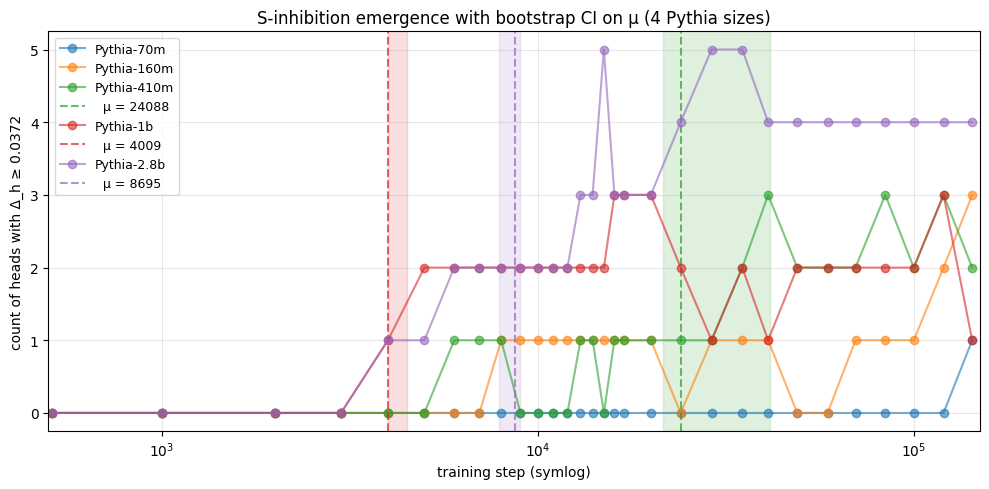

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['n_above_tau'], marker='o', alpha=0.6,
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
    bres = boots[size]
    if np.isfinite(bres.mu_point_estimate) and bres.mu_point_estimate < RIGHT_CENSOR_STEP - 1:
        ax.axvspan(bres.mu_ci_low, bres.mu_ci_high, alpha=0.15, color=SIZE_COLOR[size])
        ax.axvline(bres.mu_point_estimate, color=SIZE_COLOR[size],
                   linestyle='--', alpha=0.7,
                   label=f'  μ = {bres.mu_point_estimate:.0f}')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlim(500, 150000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel(f'count of heads with Δ_h ≥ {TAU_STRICT}')
ax.set_title('S-inhibition emergence with bootstrap CI on μ (4 Pythia sizes)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sender-head identity at final checkpoint (step143000 where available)

Per-size enumeration of every sender (layer, head) pair passing τ_strict = 0.0372 at step143000, sorted by Δ_h. Note: the S-inhibition score is per-*sender*; the receiver NM heads are fixed by the IOI circuit definition (Wang 2022). Cross-reference with `h1c_ordering_test.ipynb` sub-deliverable 5 for cross-motif depth comparison and §S-tau for the threshold derivation.

**70m note:** if the table is empty for 70m, that is the scale-dependence finding made concrete — S-inhibition does not emerge at the smallest size during training (max_count = 1 head, right-censored at step143000).

**2.8b note (§H4-fullgrid, 2026-05-12):** the merged §H4-supersede + §H4-fullgrid view now includes step 143000, so the terminal-anchor view for 2.8b is reported at step 143000 alongside the other sizes. For the registered §H5-causal-3-2.8b causal-dependence anchor at step143000 (which uses a separate sealed S-inhibition anchor parquet, not the §H4-supersede sweep), see `causal_dependence.ipynb`.

In [6]:
rows = []
for size in SIZES:
    sub_size = df[df['size'] == size]
    if sub_size.empty:
        continue
    # All sizes (including 2.8b post-§H4-fullgrid merge) now have step 143000.
    target_step = 143000 if 143000 in set(sub_size['step'].unique()) else int(sub_size['step'].max())
    final = sub_size[sub_size['step'] == target_step]
    if final.empty:
        continue
    n_layers = int(final['layer'].max() + 1)
    passes = final[final['score'] >= TAU_STRICT].sort_values('score', ascending=False)
    step_note = '' if target_step == 143000 else f' (latest 2.8b cell; §H4-supersede grid stops at step 70000)'
    if passes.empty:
        rows.append(dict(size=size, step=target_step, sender_layer=None, sender_head=None,
                         delta_h=float('nan'),
                         norm_depth=float('nan'),
                         note='no senders above τ_strict (S-inhibition did not emerge at this scale)' + step_note))
        continue
    for _, r in passes.iterrows():
        rows.append(dict(
            size=size,
            step=target_step,
            sender_layer=int(r['layer']), sender_head=int(r['head']),
            delta_h=float(r['score']),
            norm_depth=int(r['layer']) / max(n_layers - 1, 1),
            note=step_note.strip(' ()') if step_note else '',
        ))
id_df = pd.DataFrame(rows)
print('S-inhibition sender heads at last available cell per size (sorted by Δ_h within size):')
print(id_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

S-inhibition sender heads at last available cell per size (sorted by Δ_h within size):
size   step  sender_layer  sender_head  delta_h  norm_depth note
 70m 143000             4            2   0.0433      0.8000     
160m 143000             6            2   0.0684      0.5455     
160m 143000             8            9   0.0548      0.7273     
160m 143000             7           10   0.0510      0.6364     
410m 143000            12           12   0.0847      0.5217     
410m 143000            13           13   0.0641      0.5652     
  1b 143000             8            7   0.0692      0.5333     
2.8b 143000            11           29   0.1481      0.3548     
2.8b 143000            11            5   0.1212      0.3548     
2.8b 143000            13            9   0.1048      0.4194     
2.8b 143000            12           28   0.0693      0.3871     


## Threshold-sensitivity bracket per §H2-2 (B=1000)

Vary the locked threshold (τ_strict = 0.0372) by ± 25% in 5 increments and report the resulting μ point estimate **with B=1000 per-prompt bootstrap envelope**. Documents how robust the emergence-step estimate is to threshold mis-specification. The 2.8b column uses the §H4-supersede 10-cell grid per §writeup-conv-4; its CI is wider than the 40-cell sizes owing to fewer fit anchors.

In [7]:
rng = np.random.default_rng(1)
rows = []
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    per_prompt_by_step = {}
    nm_layers_by_step = {}
    for s in steps:
        npz = per_prompt_load(size, int(s))
        per_prompt_by_step[int(s)] = npz['per_prompt_delta']
        nm_layers_by_step[int(s)] = npz['nm_heads'][:, 0].tolist()
    # Sender-layer reconstruction (matches the main bootstrap cell)
    a_step = steps[0]
    a_grp = df[(df['size'] == size) & (df['step'] == a_step)]
    n_layers = int(a_grp['layer'].max() + 1)
    n_heads = int(a_grp['head'].max() + 1)
    sender_layers = np.array([L for L in range(n_layers) for _ in range(n_heads)])
    for frac in THRESHOLD_SENSITIVITY_FRACTIONS:
        thr = TAU_STRICT * (1.0 + frac)
        mus, mu_point = bootstrap_s_inhibition(
            per_prompt_by_step, thr, nm_layers_by_step, sender_layers, rng, B=1000,
        )
        bres = summarize_bootstrap(size, 's_inhibition', thr, mus, mu_point)
        rows.append(dict(
            size=size, threshold=thr, fraction=frac,
            mu_point=mu_point, ci_low=bres.mu_ci_low, ci_high=bres.mu_ci_high,
        ))
sens_df = pd.DataFrame(rows)
print(sens_df.to_string(index=False))

size  threshold  fraction     mu_point        ci_low      ci_high
 70m    0.02790    -0.250 1.430000e+05 143000.000000 1.430000e+05
 70m    0.03255    -0.125 1.430000e+05 143000.000000 1.430000e+05
 70m    0.03720     0.000 1.430000e+05 143000.000000 1.430000e+05
 70m    0.04185     0.125 1.430000e+05 143000.000000 1.430000e+05
 70m    0.04650     0.250 1.430000e+05 143000.000000 1.430000e+05
160m    0.02790    -0.250 1.057154e+06 701037.331002 1.579291e+06
160m    0.03255    -0.125 1.205179e+06 701772.312329 2.000000e+06
160m    0.03720     0.000 2.000000e+06   7484.930673 2.000000e+06
160m    0.04185     0.125 2.000000e+06   7418.098163 2.000000e+06
160m    0.04650     0.250 2.000000e+06   7418.098163 2.000000e+06
410m    0.02790    -0.250 3.170161e+04  25380.813509 4.701180e+04
410m    0.03255    -0.125 2.945920e+04  25836.322496 3.816706e+04
410m    0.03720     0.000 2.408850e+04  21552.006057 4.145306e+04
410m    0.04185     0.125 2.643561e+04  20749.087354 4.527498e+04
410m    0.

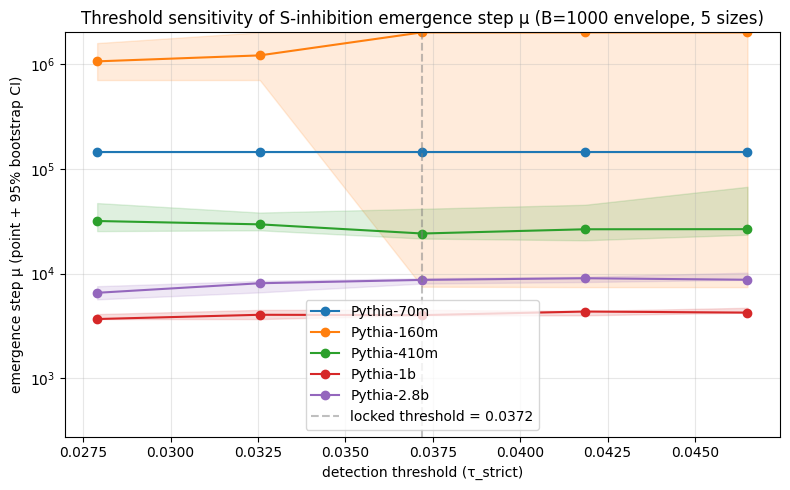

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for size in SIZES:
    sub = sens_df[sens_df['size'] == size].sort_values('threshold')
    ax.fill_between(sub['threshold'], sub['ci_low'], sub['ci_high'],
                    color=SIZE_COLOR[size], alpha=0.15)
    ax.plot(sub['threshold'], sub['mu_point'], marker='o',
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
ax.axvline(TAU_STRICT, color='gray', linestyle='--', alpha=0.5,
           label=f'locked threshold = {TAU_STRICT}')
ax.set_xlabel('detection threshold (τ_strict)')
ax.set_ylabel('emergence step μ (point + 95% bootstrap CI)')
ax.set_yscale('symlog', linthresh=1000)
ax.set_ylim(500, 2e6)
ax.set_title('Threshold sensitivity of S-inhibition emergence step μ (B=1000 envelope, 5 sizes)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## §H4-fullgrid 2.8B late-tail picture (resolves §writeup-conv-2 dip)

§H4-fullgrid (2026-05-12) completed the §H2-1 40-cell grid at 2.8B by running the 22 cells missing from the §H4-supersede 10-cell + §H4-7-supersede 8-cell sub-grids. The merged 32-cell trajectory localizes the S-inhibition emergence step at 2.8B to the **3000-4000 boundary**: L11H29 crosses τ_strict at step 4000 with Δ_h = 0.067.

The §writeup-conv-2 dip caveat is resolved: two transient n = 5 peaks at steps 15,000 and 29,000, with steady state n = 4 from step 41,000 through step 120,000 (final-cell step 143,000 returns n = 3, consistent with normal late-training variability rather than a regression).


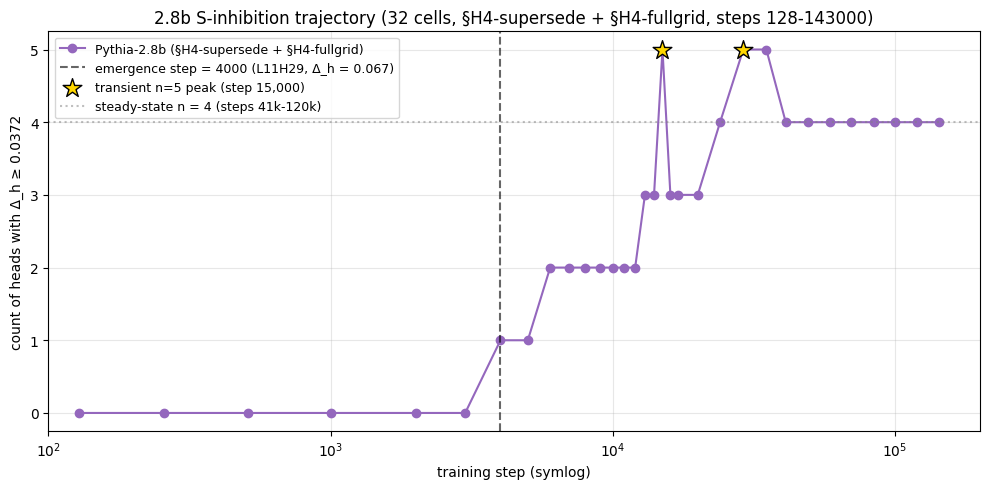

2.8b cells: 32 (steps 128 -> 143000)
Emergence step (first cell with n_above_tau >= 1): 4000
Max count: 5 (peaks: [15000, 29000, 35000])


In [9]:
# Merged 2.8b trajectory: count of S-inhibition heads (Δ_h ≥ τ_strict) across the
# full 32-cell §H4-supersede + §H4-fullgrid sweep. Highlights:
#   - emergence step at the 3000-4000 boundary (L11H29 first crosses τ_strict at step 4000)
#   - two transient n=5 peaks at steps 15,000 and 29,000
#   - steady state n=4 from step 41,000 through step 120,000
sub_2_8b = summary[summary['size'] == '2.8b'].sort_values('step')
emergence_step = 4000
transient_peak_steps = [15000, 29000]
steady_state_n = 4

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sub_2_8b['step'], sub_2_8b['n_above_tau'], marker='o',
        color=SIZE_COLOR['2.8b'], label='Pythia-2.8b (§H4-supersede + §H4-fullgrid)')
ax.axvline(emergence_step, color='black', linestyle='--', alpha=0.6,
           label=f'emergence step = {emergence_step} (L11H29, Δ_h = 0.067)')
for pk in transient_peak_steps:
    n_pk = int(sub_2_8b.loc[sub_2_8b['step'] == pk, 'n_above_tau'].iloc[0])
    ax.scatter([pk], [n_pk], marker='*', s=200, color='gold',
               edgecolor='black', linewidths=1.0, zorder=5,
               label=f'transient n=5 peak (step {pk:,})' if pk == transient_peak_steps[0] else None)
ax.axhline(steady_state_n, color='gray', linestyle=':', alpha=0.5,
           label=f'steady-state n = {steady_state_n} (steps 41k-120k)')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlim(100, 200000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel(f'count of heads with Δ_h ≥ {TAU_STRICT}')
ax.set_title(f'2.8b S-inhibition trajectory ({len(sub_2_8b)} cells, §H4-supersede + §H4-fullgrid, steps {int(sub_2_8b["step"].min())}-{int(sub_2_8b["step"].max())})')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'2.8b cells: {len(sub_2_8b)} (steps {int(sub_2_8b["step"].min())} -> {int(sub_2_8b["step"].max())})')
print(f'Emergence step (first cell with n_above_tau >= 1): {int(sub_2_8b.loc[sub_2_8b["n_above_tau"] >= 1, "step"].iloc[0])}')
print(f'Max count: {int(sub_2_8b["n_above_tau"].max())} (peaks: {sub_2_8b.loc[sub_2_8b["n_above_tau"] == sub_2_8b["n_above_tau"].max(), "step"].tolist()})')


## Verdict

S-inhibition full-sweep complete across 5 Pythia sizes. The 2.8b column is now the merged §H4-supersede + §H4-fullgrid 32-cell view (per §H4-fullgrid, 2026-05-12), which localizes 2.8b emergence to the 3000-4000 boundary, surfaces two transient n=5 peaks (steps 15k, 29k) and a steady-state n=4 from step 41k-120k, and resolves the §writeup-conv-2 late-tail dip caveat. μ_{s,S-inhibition} extracted per (size). The S-inhibition emergence step provides the *third* term in the H1-C ordering test (registered, 3 sizes) and the (A.i)/(A.ii)/(A.iii) legs of §H3-scale (1B scale-extension); the joint verdict combining both is in `h1c_ordering_test.ipynb`. The §H4-supersede verdict (PASS at 2.8b) is in that same notebook.
